# **Libraries & load data**

In [39]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [40]:
df= pd.read_csv("multi_asset_market_data.csv")

# **Data Preprocessing Steps**

In [41]:
df.shape,df.columns

((50000, 10),
 Index(['date', 'final_price', 'asset', '7d_avg', '30d_avg', 'daily_pct_change',
        'volatility_7d', 'momentum_14d', 'trend_signal', 'price_zscore'],
       dtype='object'))

In [42]:
df.head()

,date,final_price,asset,7d_avg,30d_avg,daily_pct_change,volatility_7d,momentum_14d,trend_signal,price_zscore
0,2008-07-22,$948.00,gold,964.371425,920.606667,-0.015679,10.041208,5.500000,1,0.785980
1,2006-03-20,$544.73,gold,553.832642,554.225797,0.001924,5.383550,-6.477138,0,0.280029
2,2003-11-17,$391.50,gold,390.899998,382.076668,-0.015837,5.136470,8.299988,1,1.260717
3,2006-04-28,$651.80,gold,632.499991,594.233333,0.029212,10.939685,63.399963,1,1.930167
4,2005-05-20,$6.93,silver,7.010429,7.083333,-0.025983,0.104297,0.095000,0,-1.083492


In [43]:
# Convert date
df["date"] = pd.to_datetime(df["date"], errors = 'coerce')

In [44]:
print("Data Range : ",df['date'].min()," to ",df['date'].max())

Data Range :  2000-08-30 00:00:00  to  2025-11-02 00:00:00


In [45]:
# check missing / duplicates
print("Missing Values are: \n",df.isnull().sum())
print("\nDuplicate rows :",df.duplicated().sum())

Missing Values are: 
 date                  0
final_price           0
asset                 0
7d_avg                0
30d_avg               0
daily_pct_change      0
volatility_7d         0
momentum_14d        155
trend_signal          0
price_zscore         13
dtype: int64

Duplicate rows : 0


#### Missing Value Imputation Strategy

##### Dataset Info
- **Shape:** (50,000, 10)  
- **Missing:**  
  - `momentum_14d`: 155  
  - `price_zscore`: 13  

##### Why Not Drop?
Dropping rows would **break the time sequence** and remove valuable data points.

##### Solution: Forward Fill (`ffill`)

**Reasoning:**
- **Preserves Time Flow:** Keeps data continuity.  
- **LOCF:** Uses the **last valid value** for missing entries.  
- **No Data Leakage:** Avoids using future info.  


In [46]:
df['momentum_14d'] = df['momentum_14d'].ffill()
df['price_zscore'] = df['price_zscore'].ffill()

In [47]:
# now checking missing values
df.isnull().sum()

,0
date,0
final_price,0
asset,0
7d_avg,0
30d_avg,0
daily_pct_change,0
volatility_7d,0
momentum_14d,0
trend_signal,0
price_zscore,0


**Converting final_price column to Float Dtype**

In [48]:
df["final_price"]=df["final_price"].str.replace('$','',regex=False)

In [49]:
print(df['final_price'].dtype)

object


In [50]:
# converting data Type of column from object to float
df['final_price']=pd.to_numeric(df['final_price'])

In [51]:
print(df['final_price'].dtype)

float64


**Finding Imbalance Data column**

In [52]:

# Select only numeric columns
numeric_cols = cols = ['final_price', '7d_avg', '30d_avg', 'daily_pct_change', 'volatility_7d']


print(f"Numeric Columns Found: {numeric_cols}")

# Check distribution + skewness
for col in numeric_cols:

    # Print skewness (to check balance)
    skew_value = df[col].skew()
    print(f"Skewness of {col}: {skew_value:.3f}")
    if abs(skew_value) > 1:
        print("Highly Imbalanced (Skewed distribution)")
    elif abs(skew_value) > 0.5:
        print("Moderately Imbalanced (Some skewness)")
    else:
        print("Balanced distribution")

Numeric Columns Found: ['final_price', '7d_avg', '30d_avg', 'daily_pct_change', 'volatility_7d']
Skewness of final_price: 4.974
Highly Imbalanced (Skewed distribution)
Skewness of 7d_avg: 4.980
Highly Imbalanced (Skewed distribution)
Skewness of 30d_avg: 4.983
Highly Imbalanced (Skewed distribution)
Skewness of daily_pct_change: 1.844
Highly Imbalanced (Skewed distribution)
Skewness of volatility_7d: 5.523
Highly Imbalanced (Skewed distribution)


In [53]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')  # works with 0s and negatives
cols = ['final_price', '7d_avg', '30d_avg', 'daily_pct_change', 'volatility_7d']

df_transformed = df.copy()
df_transformed[cols] = pt.fit_transform(df[cols])

# Check new skewness
print(df_transformed[cols].skew())
df=df_transformed

final_price         0.019349
7d_avg              0.019262
30d_avg             0.019118
daily_pct_change   -0.382404
volatility_7d       0.271732
dtype: float64


In [71]:
df.to_csv("Balanced_cleaned_multi_asset_market_data.csv",index=False)

# **Overall summary & quick stats**

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              50000 non-null  datetime64[ns]
 1   final_price       50000 non-null  float64       
 2   asset             50000 non-null  object        
 3   7d_avg            50000 non-null  float64       
 4   30d_avg           50000 non-null  float64       
 5   daily_pct_change  50000 non-null  float64       
 6   volatility_7d     50000 non-null  float64       
 7   momentum_14d      50000 non-null  float64       
 8   trend_signal      50000 non-null  int64         
 9   price_zscore      50000 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 3.8+ MB


In [55]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,50000,2017-04-12 17:44:28.608000,2000-08-30 00:00:00,2013-11-19 00:00:00,2019-01-16 00:00:00,2022-06-16 00:00:00,2025-11-02 00:00:00,NaN
final_price,50000.0,0.0,-1.753,-0.747218,0.063205,0.784504,2.167783,1.00001
7d_avg,50000.0,-0.0,-1.750468,-0.747042,0.064867,0.785888,2.162376,1.00001
30d_avg,50000.0,-0.0,-1.742678,-0.743538,0.071878,0.784224,2.152937,1.00001
daily_pct_change,50000.0,0.0,-16.202016,-0.298313,0.007716,0.320606,15.322608,1.00001
volatility_7d,50000.0,0.0,-1.237774,-1.03283,-0.005843,0.767619,1.96702,1.00001
momentum_14d,50000.0,60.130678,-23461.734375,-4.0,0.035889,11.171614,22984.226562,1523.790442
trend_signal,50000.0,0.51822,0.0,0.0,1.0,1.0,1.0,0.499673
price_zscore,50000.0,0.128475,-4.67515,-0.935987,0.082886,1.186037,5.229539,1.35066


**Key Insights Summary**
- **Data Range:** 50,000 records (up to 2025-11-02)  
- **Price Extremes:** Max = $126,726.96, Min = $0.14  
- **Market Volatility:** Mean = 124.79, Max = 6,446.20  
- **Average Price:** $4,380.09  
- **Recent Price Change:** +0.001207 (very slight positive drift)
  
- **Median Price:** $170.95 (much lower than mean → indicates high-price skew)
  
- **Trend Signal Consistency:** Positive trend in ~51.8% of records  


**Unique and Counts asset frequency**

In [56]:
print("Unique assets : ",df["asset"].unique())
print("\nFrequency by asset (rows):\n",df['asset'].value_counts())

Unique assets :  ['gold' 'silver' 'litecoin' 'bitcoin' 'ethereum' 'ripple']

Frequency by asset (rows):
 asset
silver      11931
gold        11881
litecoin     7612
bitcoin      7571
ripple       5524
ethereum     5481
Name: count, dtype: int64


# **Data visualisation to find the insights of the data**

## **Univariate analysis (numeric)**

<Axes: xlabel='final_price', ylabel='Count'>

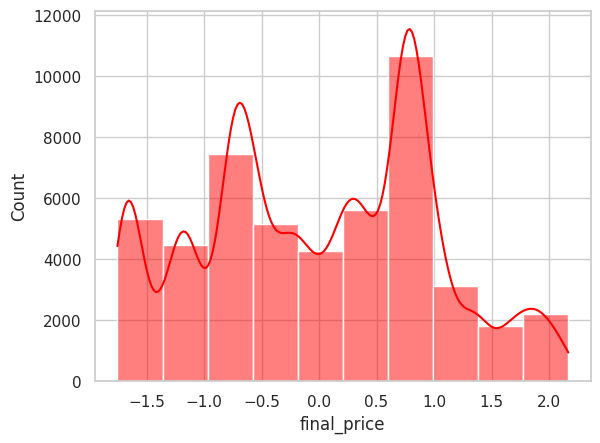

In [57]:
sns.histplot(df['final_price'],bins=10,kde=True,color = 'red')

- **key insight :**
 The distribution of final_price is bimodal, showing two main peaks—one around -1.0 and another near 0.8—indicating two dominant pricing clusters in the dataset.

<Axes: xlabel='daily_pct_change', ylabel='Count'>

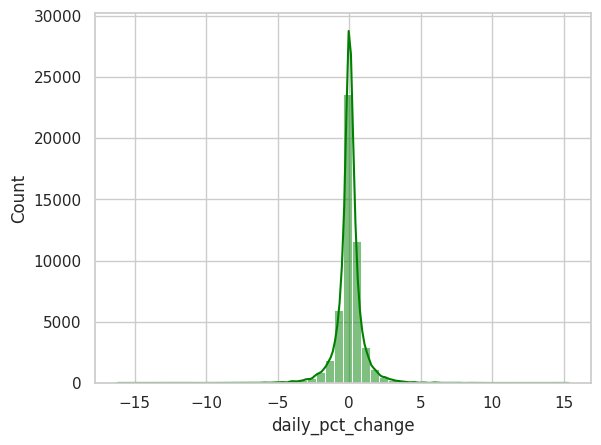

In [58]:

sns.histplot(df['daily_pct_change'],bins=50,kde=True,color = 'green')

- **key insight :**
Most daily percentage changes are very close to zero, meaning prices usually stay stable with only a few big ups or downs.

<Axes: xlabel='count', ylabel='asset'>

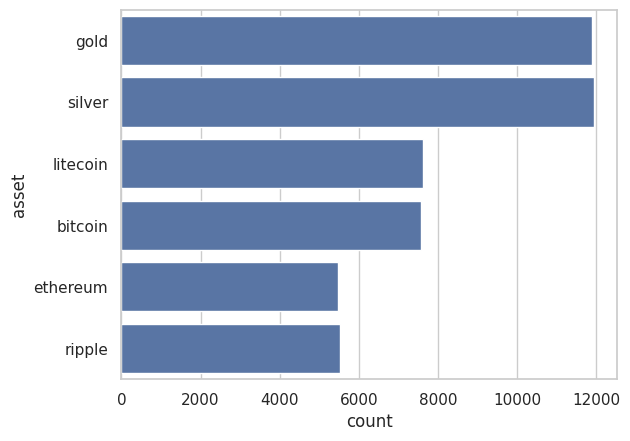

In [59]:
sns.countplot(df['asset'])

- **key insight** : Silver and gold are the most common assets in the dataset, while Ethereum and Ripple appear the least.

<Axes: xlabel='trend_signal', ylabel='count'>

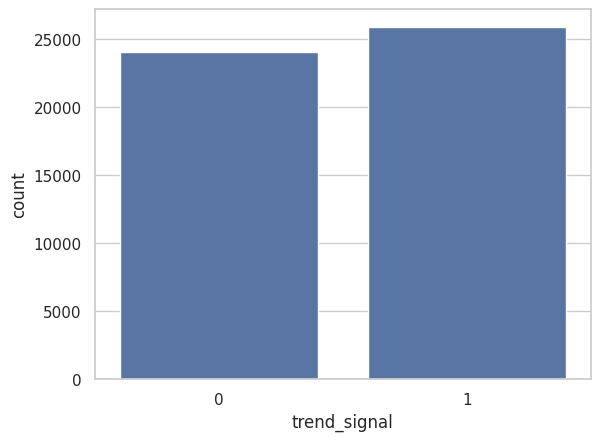

In [60]:
sns.countplot(x=df['trend_signal'])

- **key insight** :
 The dataset has almost an equal number of trend signals 0 and 1, meaning upward and downward trends are nearly balanced.


## **Bivariate Analysis**

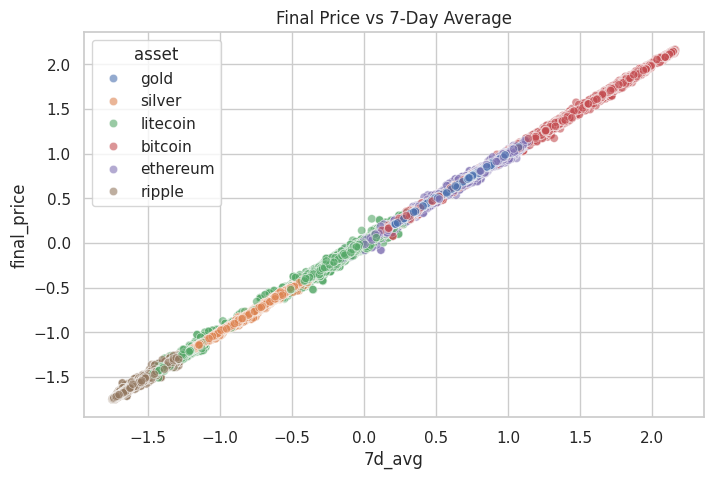

In [61]:
# ----- 1. Final Price vs 7-day Average -----
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='7d_avg', y='final_price', hue='asset', alpha=0.6)
plt.title('Final Price vs 7-Day Average')
plt.show()

**Key insight:**
The final price and 7-day average have a strong positive relationship, forming a clear upward line.
This means prices closely follow their 7-day moving average.
All assets show a similar trend pattern.

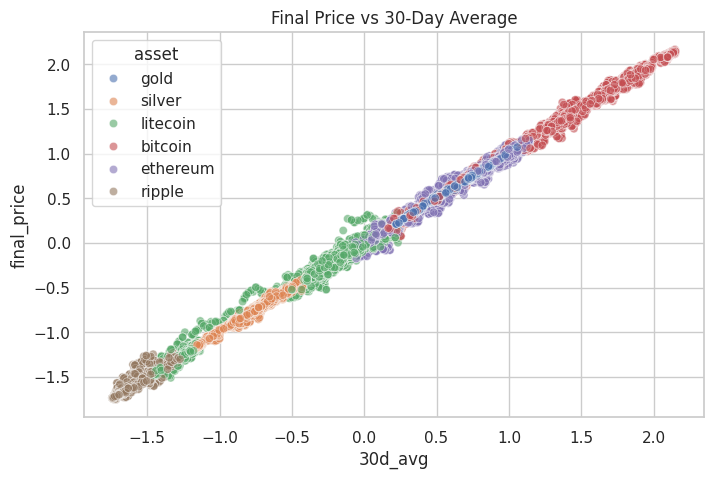

In [62]:

# ----- 2. Final Price vs 30-day Average -----
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='30d_avg', y='final_price', hue='asset', alpha=0.6)
plt.title('Final Price vs 30-Day Average')
plt.show()


**Key insight:**

The final price and 30-day average are strongly correlated, forming a near-perfect upward line.
This shows long-term stability in prices across assets.
All assets follow a similar positive trend.

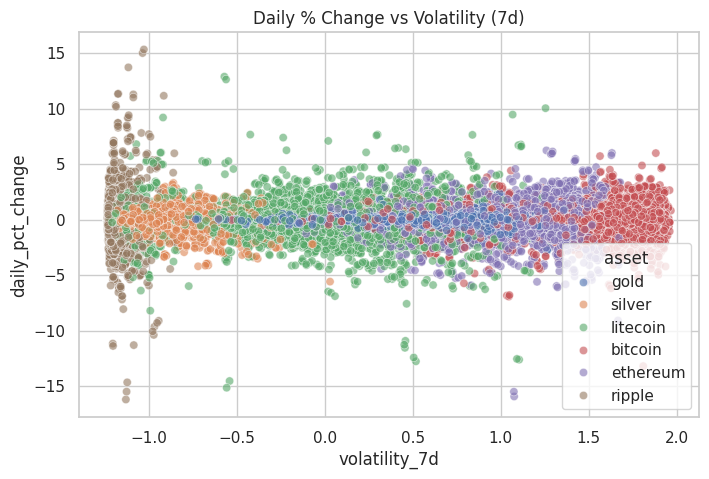

In [63]:

# ----- 3. Daily % Change vs Volatility -----
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='volatility_7d', y='daily_pct_change', hue='asset', alpha=0.6)
plt.title('Daily % Change vs Volatility (7d)')
plt.show()

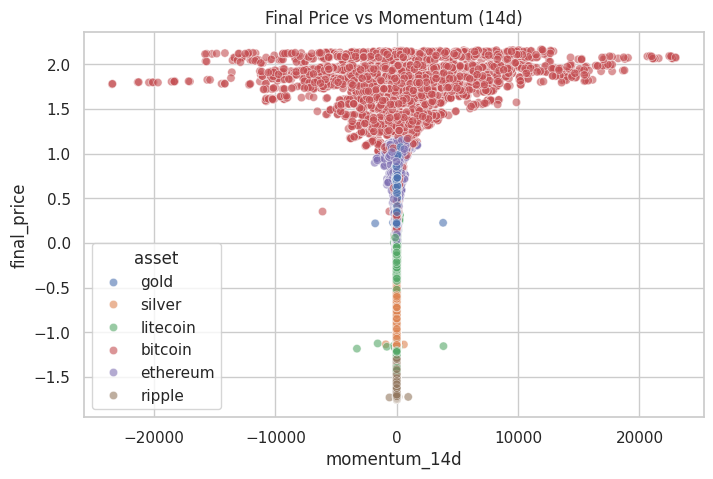

In [64]:

# ----- 4. Final Price vs Momentum -----
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='momentum_14d', y='final_price', hue='asset', alpha=0.6)
plt.title('Final Price vs Momentum (14d)')
plt.show()


**Key insight:**

As volatility increases, the daily percentage change becomes more spread out.
This means higher volatility leads to larger price swings.
Ripple shows the widest variation compared to other assets.

## **Multivariate Analysis**

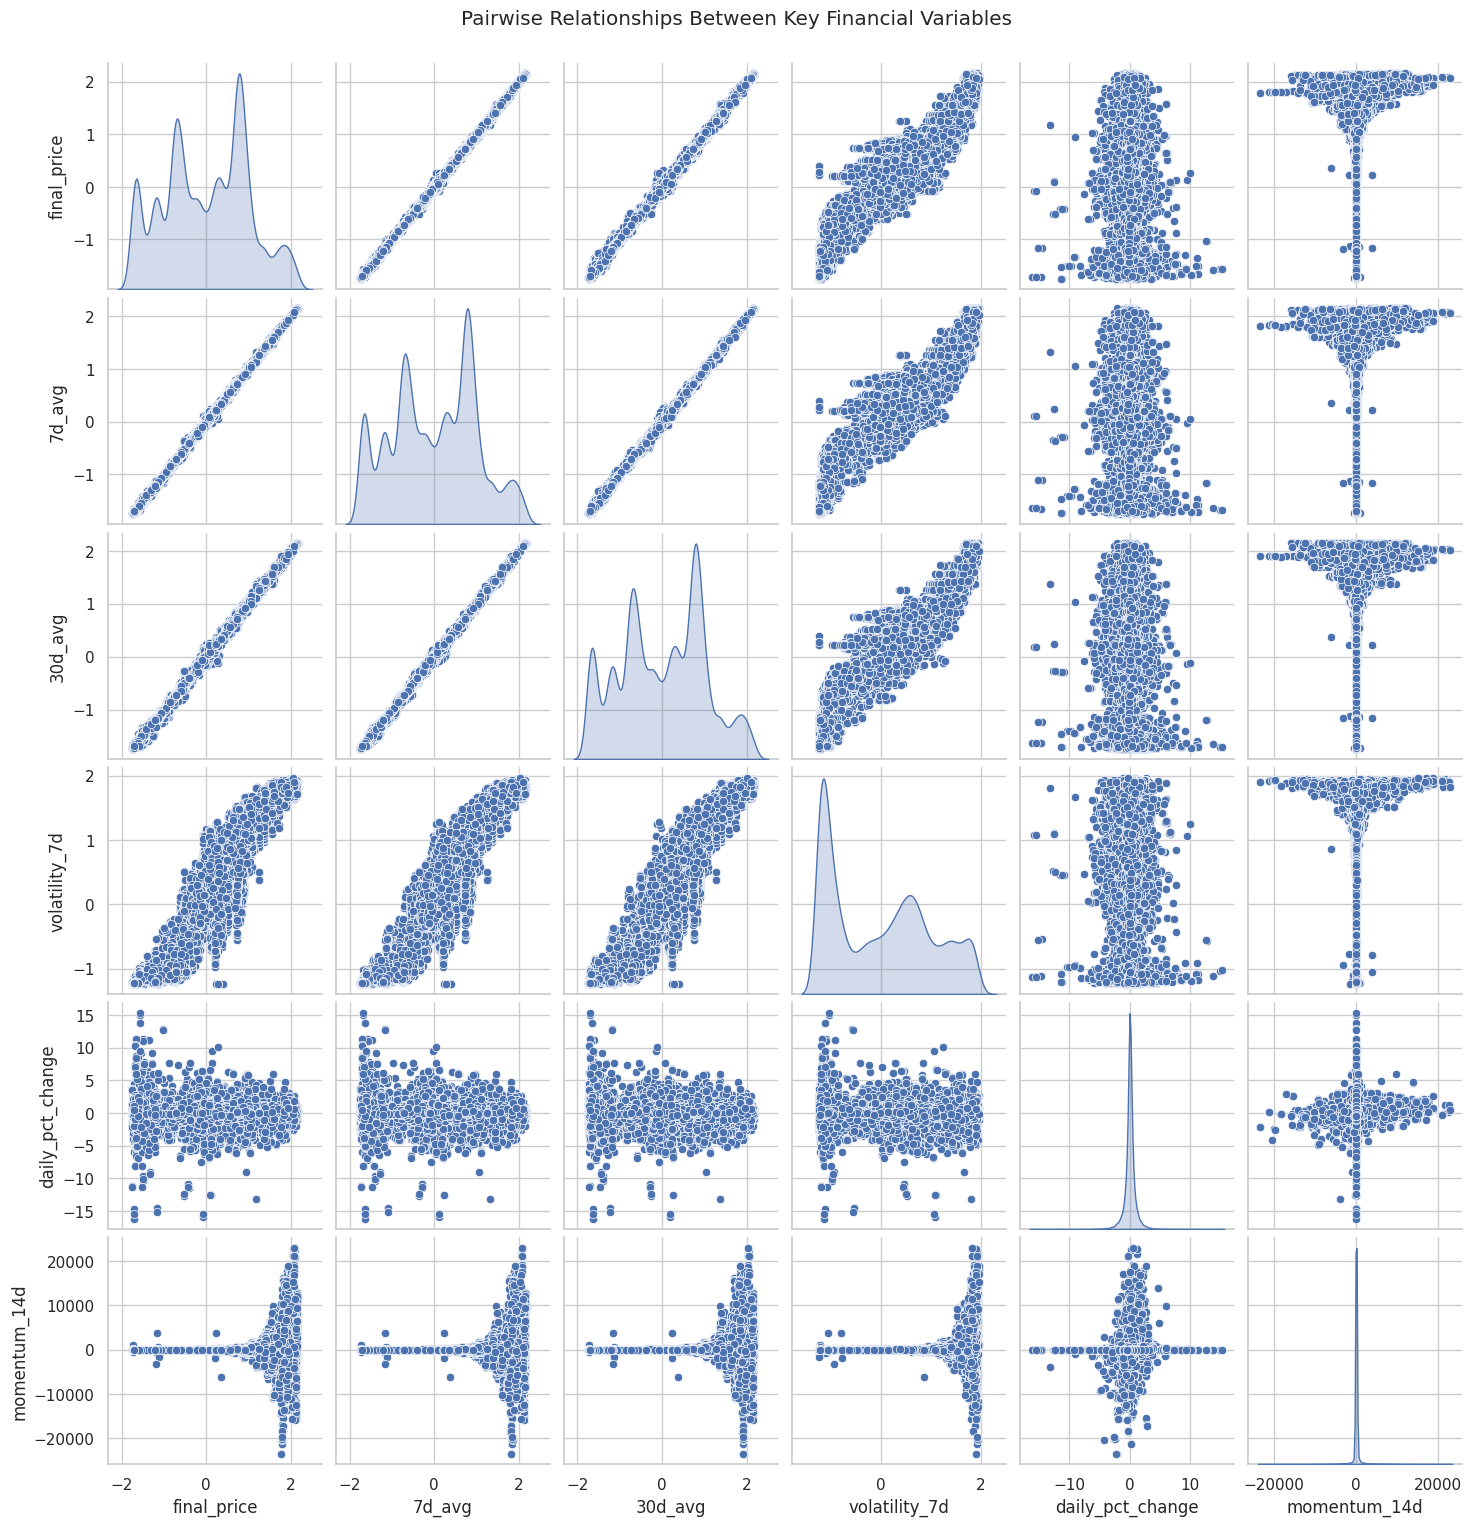

In [65]:
# ----- 1. Pairplot (Multiple relationships at once) -----
sns.pairplot(df[['final_price', '7d_avg', '30d_avg', 'volatility_7d', 'daily_pct_change', 'momentum_14d']], diag_kind='kde')
plt.suptitle('Pairwise Relationships Between Key Financial Variables', y=1.02)
plt.show()


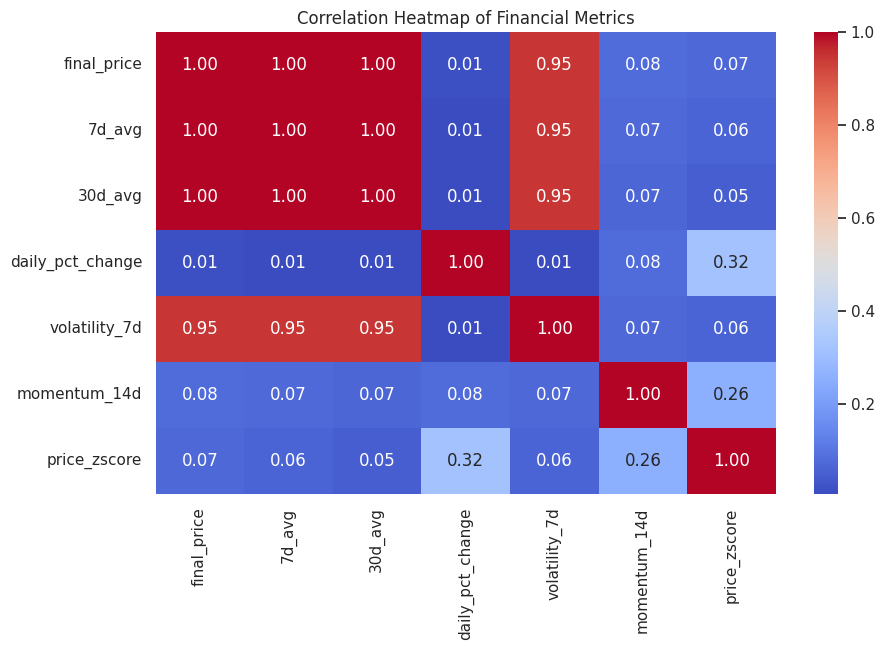

In [66]:
# ----- 2. Correlation Heatmap -----
plt.figure(figsize=(10,6))
corr = df[['final_price', '7d_avg', '30d_avg', 'daily_pct_change', 'volatility_7d', 'momentum_14d', 'price_zscore']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Financial Metrics')
plt.show()

**Key insight:**

Final price, 7-day, and 30-day averages are almost perfectly correlated (correlation ≈ 1.00).
Volatility also has a strong positive link with these price metrics.
Daily % change and other indicators show very weak correlations.

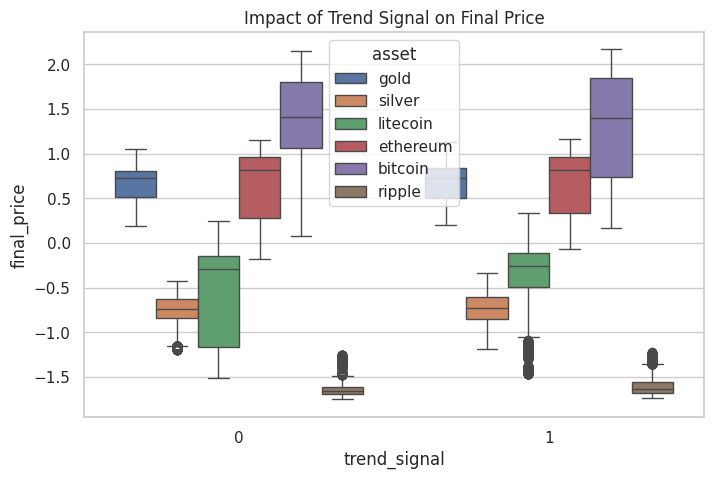

In [67]:

# ----- 3. Trend Signal Effect -----
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='trend_signal', y='final_price', hue='asset')
plt.title('Impact of Trend Signal on Final Price')
plt.show()

**Key insight:**

When the trend signal is 1, final prices are generally higher than when it’s 0.
This means a positive trend signal is linked with price increases.
Bitcoin and Ethereum show the strongest positive impact.

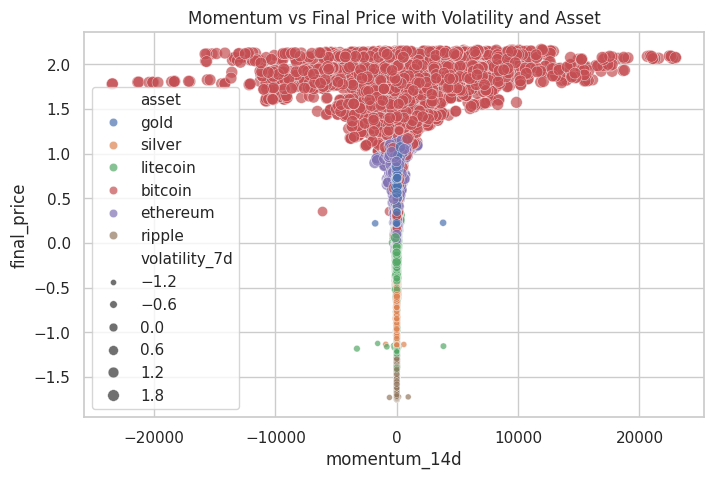

In [68]:

# ----- 4. Multivariate Scatter with Color and Size -----
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='momentum_14d',
    y='final_price',
    hue='asset',
    size='volatility_7d',
    alpha=0.7
)
plt.title('Momentum vs Final Price with Volatility and Asset')
plt.show()


**Key insight:**

Most assets cluster near zero momentum, showing limited short-term movement.
Higher momentum values are linked with higher final prices, especially for Bitcoin.
Volatility slightly increases with stronger momentum.

In [69]:
df[['final_price', '7d_avg', '30d_avg', 'daily_pct_change', 'volatility_7d', 'momentum_14d', 'price_zscore']].corr()


,final_price,7d_avg,30d_avg,daily_pct_change,volatility_7d,momentum_14d,price_zscore
final_price,1.000000,0.999895,0.999455,0.014777,0.947588,0.075898,0.069898
7d_avg,0.999895,1.000000,0.999663,0.006300,0.947699,0.073426,0.061492
30d_avg,0.999455,0.999663,1.000000,0.005098,0.946987,0.067047,0.045440
daily_pct_change,0.014777,0.006300,0.005098,1.000000,0.007051,0.075754,0.316756
volatility_7d,0.947588,0.947699,0.946987,0.007051,1.000000,0.069526,0.060754
momentum_14d,0.075898,0.073426,0.067047,0.075754,0.069526,1.000000,0.256548
price_zscore,0.069898,0.061492,0.045440,0.316756,0.060754,0.256548,1.000000


/tmp/ipython-input-2618324377.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('asset').apply(lambda x: x.iloc[::10]).reset_index(drop=True)


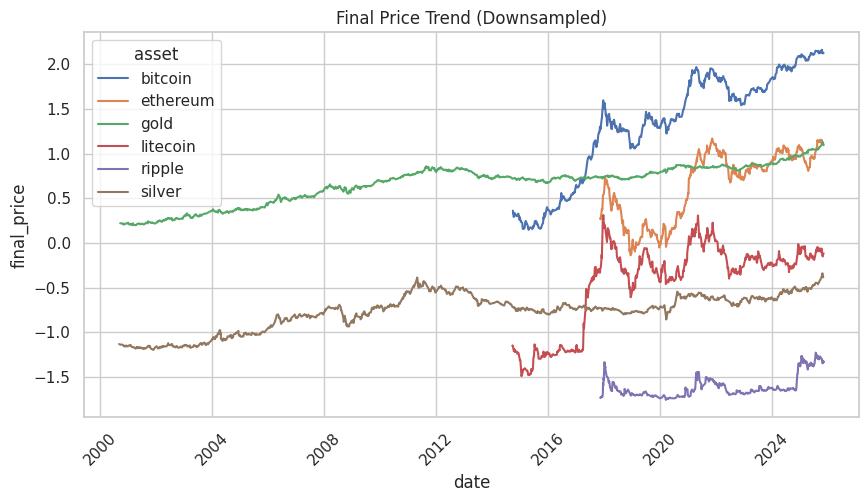

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Downsample data (keep every 10th record)
df_sampled = df.groupby('asset').apply(lambda x: x.iloc[::10]).reset_index(drop=True)

plt.figure(figsize=(10,5))
sns.lineplot(x='date', y='final_price', hue='asset', data=df_sampled)
plt.title("Final Price Trend (Downsampled)")
plt.xticks(rotation=45)
plt.show()


**Key insight:**

Bitcoin and Ethereum show the highest growth over time, while gold remains steady.
Ripple and silver stay mostly low and stable.
Overall, crypto assets are more volatile than traditional ones.

# **Analysis Summary**

The data shows a clear picture of how different financial assets behave over time. Gold and silver are the most common assets in the dataset, while Ethereum and Ripple appear less often. The daily percentage change mostly stays around zero, meaning prices usually remain stable with only a few big moves. Both the 7-day and 30-day averages have a very strong positive relationship with the final price, showing that prices follow their moving averages closely. When volatility increases, price changes become larger and more spread out — especially for Ripple. The correlation heatmap confirms that final price, 7-day, and 30-day averages are almost perfectly linked, while other features like momentum and daily change have weak connections. Trend signals also play a role — when the signal is 1, prices are generally higher, particularly for Bitcoin and Ethereum. Momentum has a small impact, but higher momentum slightly increases volatility and price levels. Over time, Bitcoin and Ethereum show the highest growth and biggest fluctuations, while gold remains stable and Ripple and silver stay mostly low. Overall, the data tells a story of how cryptocurrencies are dynamic and volatile, while traditional assets like gold and silver are steady and reliable.